In [9]:
!pip install google_play_scraper
!pip install textblob

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [10]:
!pip install matplotlib

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [11]:
from google_play_scraper import app , Sort , reviews_all
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as dates

In [12]:
nhs_reviews = reviews_all(
    'uk.nhs.covid19.production',
    sleep_milliseconds=0,
    lang='en',
    sort=Sort.NEWEST
)



In [14]:
print(nhs_reviews[:5])

[{'reviewId': 'd2cdcb4b-040a-4ddb-86c9-310f0a88122c', 'userName': 'A Google user', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g', 'content': 'uninstall', 'score': 1, 'thumbsUpCount': 0, 'reviewCreatedVersion': None, 'at': datetime.datetime(2025, 4, 4, 4, 34, 28), 'replyContent': None, 'repliedAt': None, 'appVersion': None}, {'reviewId': '5d738494-3a20-4805-a3e1-71606fbd6a2b', 'userName': 'A Google user', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g', 'content': 'dont nee any more', 'score': 5, 'thumbsUpCount': 0, 'reviewCreatedVersion': '6.0 (358)', 'at': datetime.datetime(2025, 3, 18, 16, 41, 22), 'replyContent': None, 'repliedAt': None, 'appVersion': '6.0 (358)'}, {'reviewId': 'e1124939-ef41-462a-9a76-1c598564baf4', 'userName': 'A Google user', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXm

In [15]:
df_nhsrev = pd.DataFrame(np.array(nhs_reviews),columns=['content'])
df_nhsrev = df_nhsrev.join(pd.DataFrame(df_nhsrev.pop('content').tolist()))
df_nhsrev.to_csv(r'C:\Users\USER\Documents\PBA\SentimentAnalysis\df_nhsrev.csv',index=False)
df_nhsrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d2cdcb4b-040a-4ddb-86c9-310f0a88122c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,uninstall,1,0,None,2025-04-04 04:34:28,None,NaT,None
1,5d738494-3a20-4805-a3e1-71606fbd6a2b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,dont nee any more,5,0,6.0 (358),2025-03-18 16:41:22,None,NaT,6.0 (358)
2,e1124939-ef41-462a-9a76-1c598564baf4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Don't use it,5,0,6.0 (358),2025-02-05 13:57:50,None,NaT,6.0 (358)
3,b23aae88-6c3b-4946-8d95-d244ff5e0cfc,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very useful,5,0,None,2025-01-23 22:33:18,None,NaT,None
4,890d44dc-4ebf-4aa3-a19c-300915076816,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Good App .....,4,0,6.0 (358),2025-01-05 12:05:49,None,NaT,6.0 (358)


In [17]:
#clean the content column (impossible because we cannot control people's reviews) 
# EDA (Explnatory Data Analysis ) 
#1. size of the data :
def shape(df):
    rows,col = df.shape
    print(f"the dataset contains {rows} reviews and {col} columns.")
shape(df_nhsrev)

the dataset contains 23117 reviews and 11 columns.


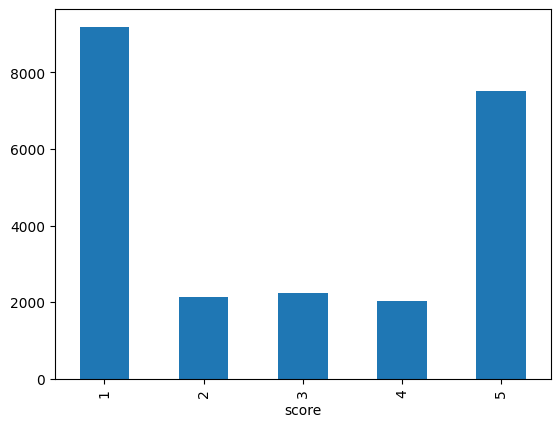

In [62]:
#2. rating distribution : to evaluate the order through the data score. 
#It is stated the valued for the highest stake comes down at 1 rating (39.74%) while the lowest at 4 rating (8.78%). 
df_rating = df_nhsrev["score"].value_counts().sort_index().plot(kind="bar")



In [64]:
def rating_summarize(df): 
    rating_score = df_nhsrev['score'].value_counts().sort_index()
    total = len(df)

    for rating, count in rating_score.items():
         percent = round((count/total)*100,2)
         print(f"{rating} star : {count} reviews ({percent}%)")
rating_summarize(df_nhsrev)

1 star : 9186 reviews (39.74%)
2 star : 2129 reviews (9.21%)
3 star : 2249 reviews (9.73%)
4 star : 2030 reviews (8.78%)
5 star : 7523 reviews (32.54%)


In [22]:
df_nhsrev["review_length"] = df_nhsrev.content.str.len()
df_nhsrev["review_length"].describe()

count    23117.000000
mean       131.755375
std        134.221981
min          1.000000
25%         31.000000
50%         84.000000
75%        188.000000
max       1818.000000
Name: review_length, dtype: float64

In [24]:
#3. Checking most common words 
all_text = " ".join(df_nhsrev["content"].astype(str))
print(all_text[:500])

uninstall dont nee any more Don't use it Very useful Good App ..... Not interested Excellent communication Tabah I hope never to need it again Rubbish Zeis- I was taken to hospital,& didn't know where I was. I was confused & they didn't help that the nurses. It was bad for me & after they let me go home, but even now I didn't know if I had COVID not. I had wonder if needed an injection again or not. My age is 72. It's outdated now Very good It was so good fantastic Very good A good platform than


In [26]:
#DATA PREPROCESSING
# Lower casing

# Change the reviews type to string
df_nhsrev['content'] = df_nhsrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_nhsrev['content'].head())

0            uninstall
1    dont nee any more
2         Don't use it
3          Very useful
4       Good App .....
Name: content, dtype: object


In [27]:
#lowercasing the reviews 
#Lowercase all reviews to see the difference
df_nhsrev['content']= df_nhsrev['content'].apply(lambda x: x.lower())
print(df_nhsrev['content'].head())

0            uninstall
1    dont nee any more
2         don't use it
3          very useful
4       good app .....
Name: content, dtype: object


In [30]:
#REMOVE PUNCTUATION 
import re

df_nhsrev["content"] = df_nhsrev["content"].apply(lambda x: re.sub(r"[^\w\s]", "", x))
print(df_nhsrev["content"].tail())

23112    tells me is installed but not on phone cant ge...
23113    the emails from the nhs could do a better job ...
23114    seems to work really well super simple setup p...
23115                  not able to install code didnt work
23116    where can i get a code the instructions is not...
Name: content, dtype: object


In [32]:
#REMOVE STOPWORDS
!pip install nltk
import nltk
nltk.download('stopwords')

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [45]:
from nltk.corpus import stopwords
from nltk.probability import FreqDist
stop_words = set(stopwords.words("english"))

In [46]:
df_nhsrev["content"] = df_nhsrev["content"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

In [36]:
df_nhsrev["content"].tail()

23112    tells installed phone cant get far putting cod...
23113    emails nhs could better job highlighting acces...
23114    seems work really well super simple setup peop...
23115                         able install code didnt work
23116                          get code instructions clear
Name: content, dtype: object

In [37]:
df_nhsrev.to_csv(
"C:/Users/USER/Documents/PBA/SentimentAnalysis/nhs_clean_reviews.csv",
index=False
)

In [55]:
!pip install seaborn

     -------------------------------------- 294.9/294.9 KB 1.2 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [58]:
#COUNT WORD FREQUENCY 

import seaborn as sns
import matplotlib.pyplot as plt
def freq_words(x, terms = 30):
    all_words = ''.join([text for text in x])
    all_words = all_words.split()

    fdist = FreqDist(all_words)
    words_df_nhsrev = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

    #Selecting top 20 most frequent words 
    
    d = words_df_nhsrev.nlargest(columns="count", n = terms)
    plt.figure(figsize=(20,5))
    ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")
    ax.set(ylabel="Count")
    plt.show()
    
    
    
    

C:\Users\USER\AppData\Local\Temp\ipykernel_7396\546779942.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


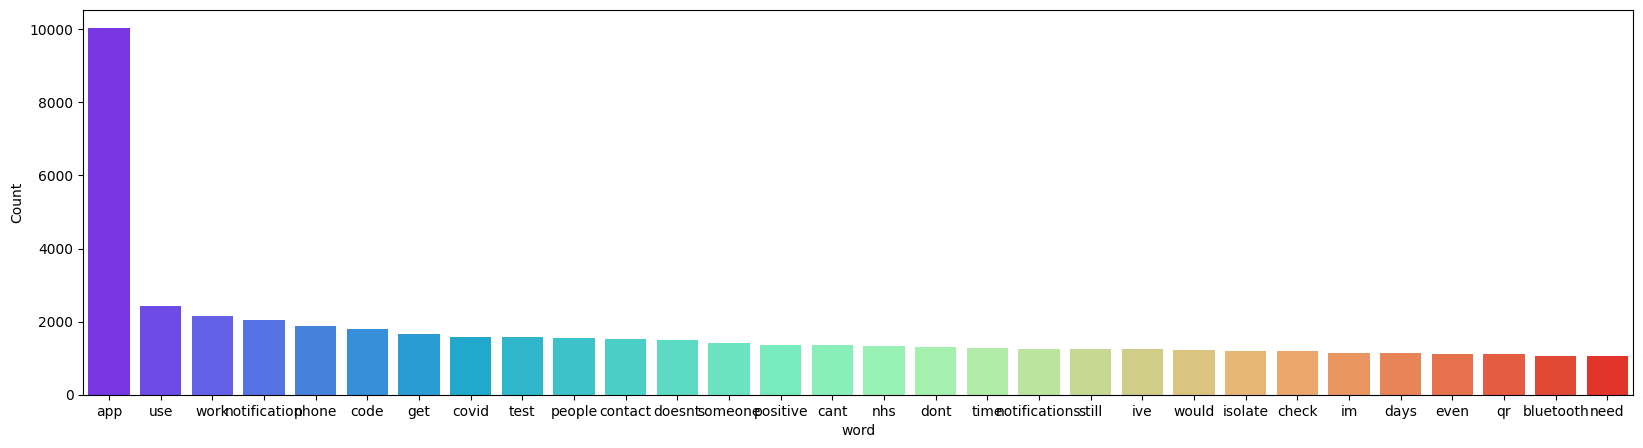

In [59]:
freq_words(df_nhsrev['content'])